In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.pca import fit_pca, pca_top_loadings, pca_scree_data, save_pca_results, PCAConfig

sns.set(style="whitegrid", context="notebook")

RESULTS_DIR = PROJECT_ROOT / "results" / "embeddings"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

#### Loading preprocessed data

In [ ]:
# loading both preprocessing pipelines from 02_preprocessing
DATA_DIR = PROJECT_ROOT / "data" / "processed"

X_global = np.load(DATA_DIR / "pipeline_A_global_X.npy")
X_centered = np.load(DATA_DIR / "pipeline_B_centered_X.npy")
y = np.load(DATA_DIR / "pipeline_A_global_y.npy")
meta = pd.read_csv(DATA_DIR / "pipeline_A_global_metadata.csv")

# loading feature names
import json
with open(DATA_DIR / "pipeline_A_global_info.json", "r") as f:
    info = json.load(f)

from src.data.load_data import load_feature_data
loaded = load_feature_data()
feature_names = [c for c in loaded.features.columns 
                 if c not in info.get("dropped_cols", [])]

print(f"X_global shape:   {X_global.shape}")
print(f"X_centered shape: {X_centered.shape}")
print(f"y shape:          {y.shape}")
print(f"y values:         {np.unique(y)}")
print(f"Feature names:    {len(feature_names)}")
print(f"Metadata shape:   {meta.shape}")

X_global shape:   (312, 51)
X_centered shape: (312, 51)
y shape:          (312,)
y values:         [0 1 2]
Feature names:    51
Metadata shape:   (312, 19)


#### Label mappings for plots

In [3]:
# phase labels for coloring
phase_labels = meta["Phase"].values
phase_display = np.where(phase_labels == "phase1", "Pre-rest",
                np.where(phase_labels == "phase2", "Puzzle", "Post-rest"))

# individual labels
individual_labels = meta["Individual"].values

# role labels
puzzler_labels = np.where(meta["Puzzler"].values == 1, "Puzzler", "Instructor")

# round labels
round_labels = meta["Round"].values

print("Label arrays created:")
print(f"  Phases:      {np.unique(phase_display)}")
print(f"  Individuals: {len(np.unique(individual_labels))} unique")
print(f"  Roles:       {np.unique(puzzler_labels)}")
print(f"  Rounds:      {np.unique(round_labels)}")

Label arrays created:
  Phases:      ['Post-rest' 'Pre-rest' 'Puzzle']
  Individuals: 26 unique
  Roles:       ['Instructor' 'Puzzler']
  Rounds:      ['round_1' 'round_2' 'round_3' 'round_4']


#### fit PCA on both pipelines

In [4]:
cfg = PCAConfig(n_components=None)  # keep all components

pca_global = fit_pca(X_global, feature_names, cfg)
pca_centered = fit_pca(X_centered, feature_names, cfg)

print("=== Pipeline A: Global ===")
print(f"  Scores shape:    {pca_global.scores.shape}")
print(f"  PC1 explains:    {pca_global.explained_variance_ratio[0]:.1%}")
print(f"  PC1+PC2 explain: {pca_global.cumulative_variance[1]:.1%}")
print(f"  PCs for 80%:     {np.searchsorted(pca_global.cumulative_variance, 0.80) + 1}")
print(f"  PCs for 90%:     {np.searchsorted(pca_global.cumulative_variance, 0.90) + 1}")

print(f"\n=== Pipeline B: Subject-centered ===")
print(f"  Scores shape:    {pca_centered.scores.shape}")
print(f"  PC1 explains:    {pca_centered.explained_variance_ratio[0]:.1%}")
print(f"  PC1+PC2 explain: {pca_centered.cumulative_variance[1]:.1%}")
print(f"  PCs for 80%:     {np.searchsorted(pca_centered.cumulative_variance, 0.80) + 1}")
print(f"  PCs for 90%:     {np.searchsorted(pca_centered.cumulative_variance, 0.90) + 1}")

=== Pipeline A: Global ===
  Scores shape:    (312, 51)
  PC1 explains:    27.8%
  PC1+PC2 explain: 37.9%
  PCs for 80%:     11
  PCs for 90%:     17

=== Pipeline B: Subject-centered ===
  Scores shape:    (312, 51)
  PC1 explains:    16.1%
  PC1+PC2 explain: 25.5%
  PCs for 80%:     14
  PCs for 90%:     19


**Finding:** PC1 drops from 27.8% to 16.1% after subject-centering. This means approximately 12 percentage points of PC1 variance in pipeline A was capturing inter-subject baseline differences rather than phase-related physiological variation. The data is not strongly low-dimensional, 11-14 PCs are needed for 80% variance, indicating a complex, multi-signal feature space with no simple 2-3 dimensional summary.

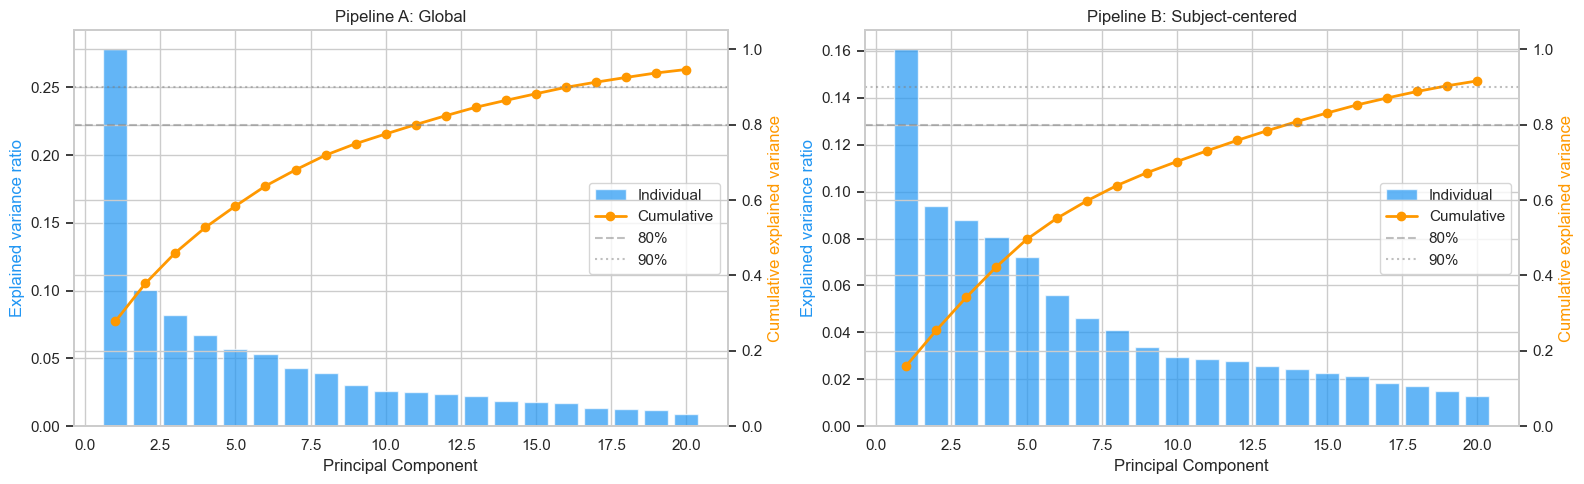

In [5]:
# scree plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, result, title in [
    (axes[0], pca_global, "Pipeline A: Global"),
    (axes[1], pca_centered, "Pipeline B: Subject-centered"),
]:
    scree = pca_scree_data(result, max_components=20)

    color1 = "#2196F3"
    color2 = "#FF9800"

    # bar plot for individual variance
    ax.bar(scree["PC_number"], scree["explained_variance"],
           alpha=0.7, color=color1, label="Individual")

    # line plot for cumulative variance
    ax2 = ax.twinx()
    ax2.plot(scree["PC_number"], scree["cumulative_variance"],
             "o-", color=color2, linewidth=2, label="Cumulative")
    ax2.set_ylabel("Cumulative explained variance", color=color2)
    ax2.set_ylim(0, 1.05)
    ax2.axhline(y=0.8, color="gray", linestyle="--", alpha=0.5, label="80%")
    ax2.axhline(y=0.9, color="gray", linestyle=":", alpha=0.5, label="90%")

    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Explained variance ratio", color=color1)
    ax.set_title(title)

    # combining legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "scree_plots.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Neither pipeline shows a clear "elbow" in the scree plot. Pipeline A has a dominant first component (individual baselines) followed by gradual decay. Pipeline B has shows a more even distribution of variance across components, consistent with removing the dominant source of variation. The 80% and 90% thresholds require many components in both cases, confirming high-intrinsic dimensionality of he physiological feature space.

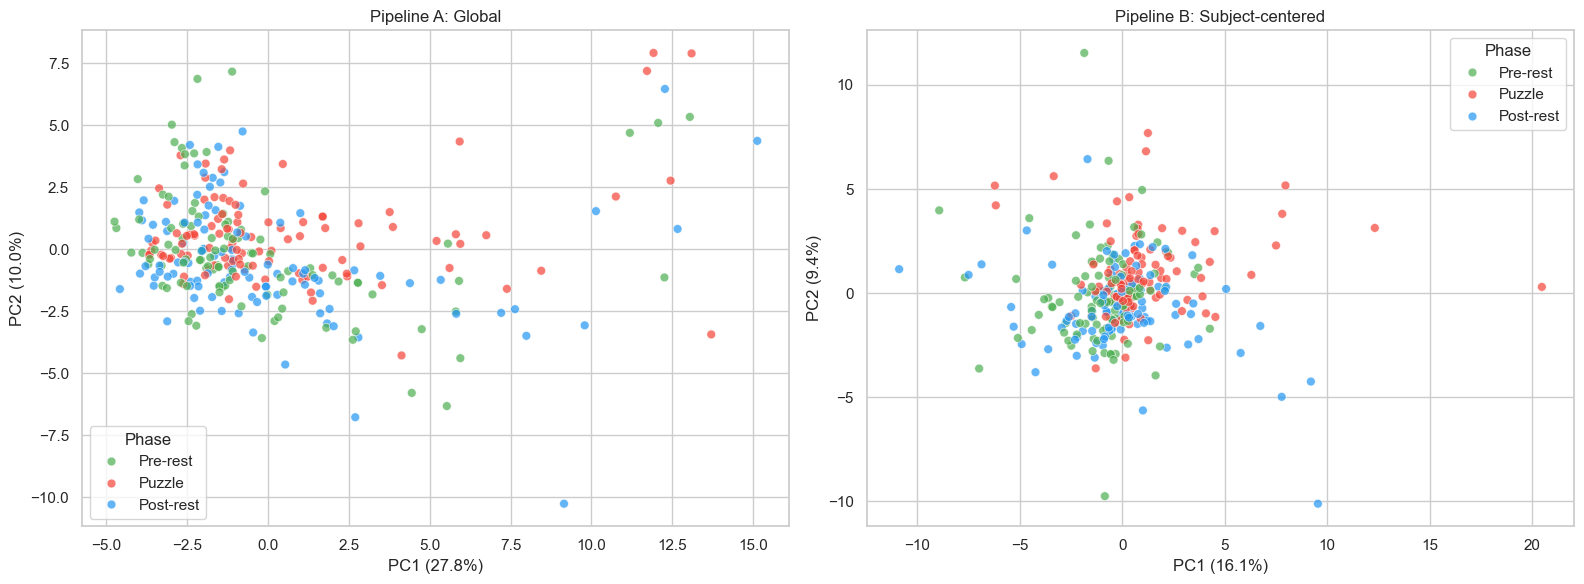

In [6]:
# scree plots, cloured by phase
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, result, title in [
    (axes[0], pca_global, "Pipeline A: Global"),
    (axes[1], pca_centered, "Pipeline B: Subject-centered"),
]:
    scatter_df = pd.DataFrame({
        "PC1": result.scores[:, 0],
        "PC2": result.scores[:, 1],
        "Phase": phase_display,
    })

    sns.scatterplot(
        data=scatter_df, x="PC1", y="PC2", hue="Phase",
        hue_order=["Pre-rest", "Puzzle", "Post-rest"],
        palette={"Pre-rest": "#4CAF50", "Puzzle": "#F44336", "Post-rest": "#2196F3"},
        alpha=0.7, s=40, ax=ax,
    )

    var1 = result.explained_variance_ratio[0]
    var2 = result.explained_variance_ratio[1]
    ax.set_xlabel(f"PC1 ({var1:.1%})")
    ax.set_ylabel(f"PC2 ({var2:.1%})")
    ax.set_title(title)
    ax.legend(title="Phase")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_by_phase.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** In both pipelines, the three phases (pre-rest, puzzle, and post-rest) show heavy overlap i the PC1-PC2 plane. No clear phase separation is visible. This suggests that the first two principal components, even after subject-centerng, do not capture sufficient phase-discriminative information for visual separation.

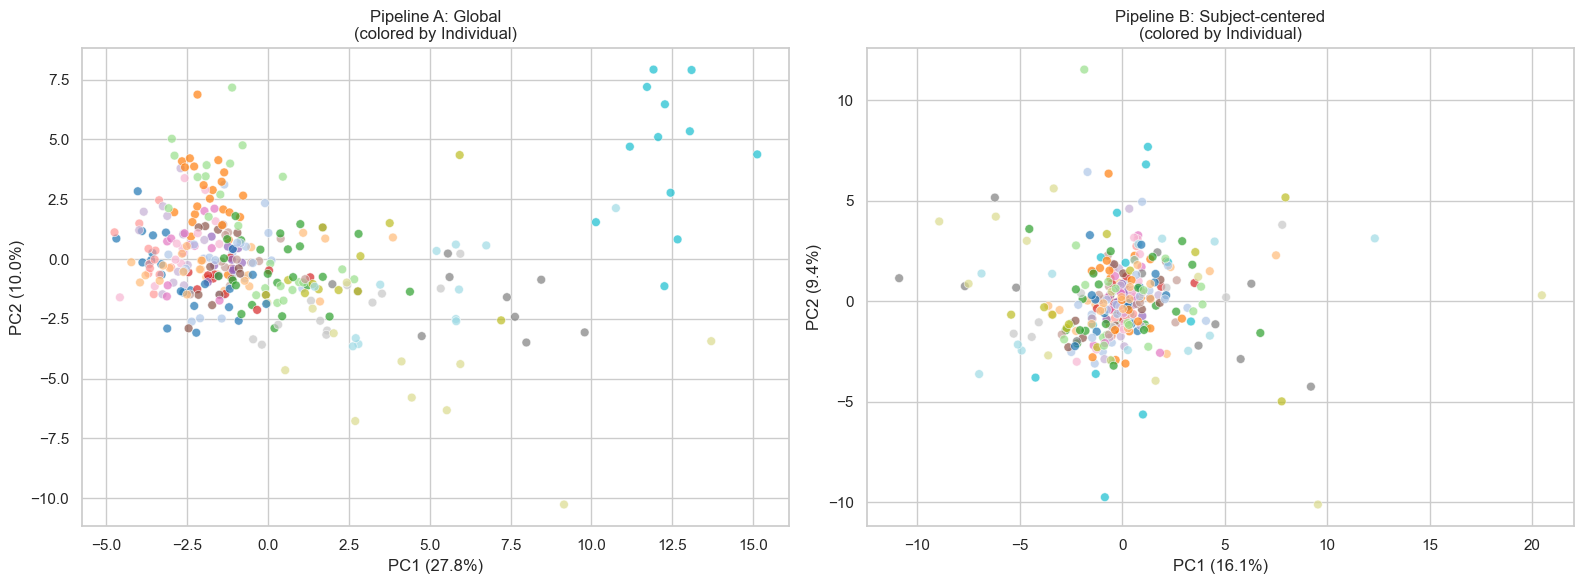

In [7]:
# score plots, coloured by individual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, result, title in [
    (axes[0], pca_global, "Pipeline A: Global"),
    (axes[1], pca_centered, "Pipeline B: Subject-centered"),
]:
    scatter_df = pd.DataFrame({
        "PC1": result.scores[:, 0],
        "PC2": result.scores[:, 1],
        "Individual": individual_labels.astype(str),
    })

    sns.scatterplot(
        data=scatter_df, x="PC1", y="PC2", hue="Individual",
        palette="tab20", alpha=0.7, s=40, ax=ax, legend=False,
    )

    var1 = result.explained_variance_ratio[0]
    var2 = result.explained_variance_ratio[1]
    ax.set_xlabel(f"PC1 ({var1:.1%})")
    ax.set_ylabel(f"PC2 ({var2:.1%})")
    ax.set_title(f"{title}\n(colored by Individual)")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_by_individual.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** in pipeline A, points from the same individual cluster tightly together, confirming that PCA captures individual identity rather than experimental condition. In pipeline B, individual clusters are much less distinct, demonstrating that subject-centering successfully removed baseline-driven structure. This could be a strong evidence that raw physiological features can be dominated by who the participant is, not what phase they are in.

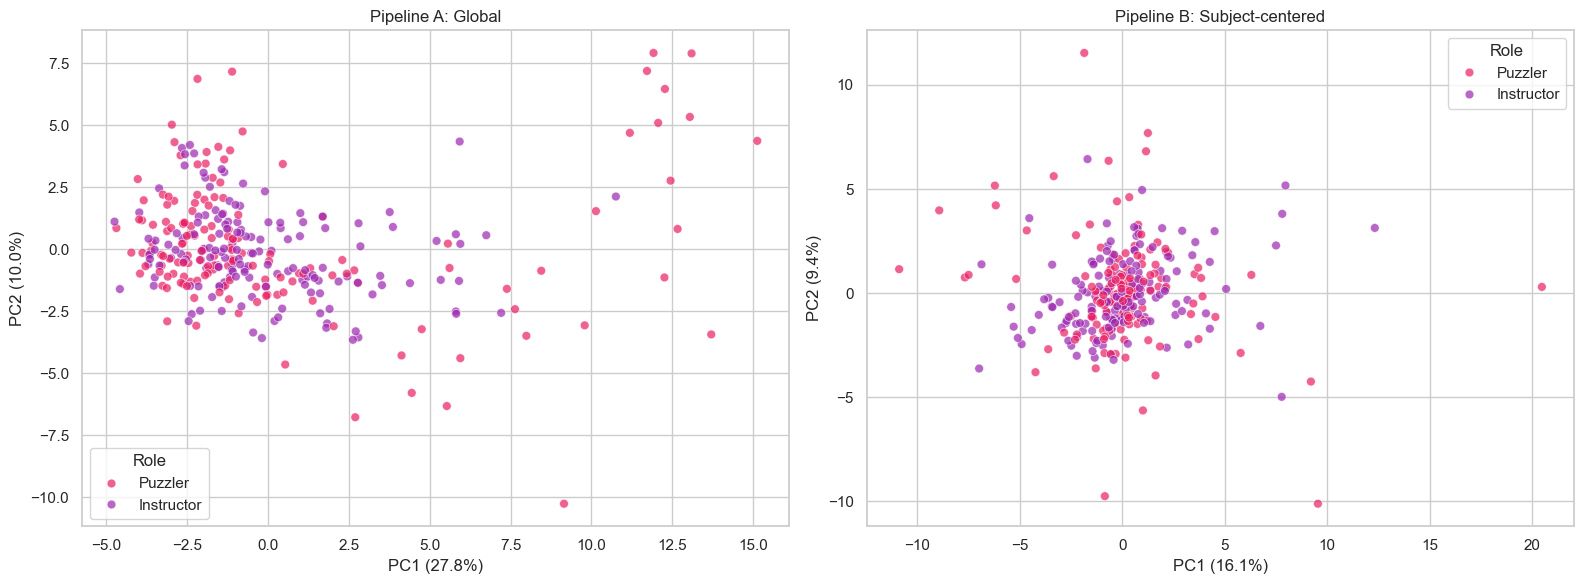

In [8]:
# pca score plots, coloured by role
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, result, title in [
    (axes[0], pca_global, "Pipeline A: Global"),
    (axes[1], pca_centered, "Pipeline B: Subject-centered"),
]:
    scatter_df = pd.DataFrame({
        "PC1": result.scores[:, 0],
        "PC2": result.scores[:, 1],
        "Role": puzzler_labels,
    })

    sns.scatterplot(
        data=scatter_df, x="PC1", y="PC2", hue="Role",
        palette={"Puzzler": "#E91E63", "Instructor": "#9C27B0"},
        alpha=0.7, s=40, ax=ax,
    )

    var1 = result.explained_variance_ratio[0]
    var2 = result.explained_variance_ratio[1]
    ax.set_xlabel(f"PC1 ({var1:.1%})")
    ax.set_ylabel(f"PC2 ({var2:.1%})")
    ax.set_title(title)
    ax.legend(title="Role")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_by_role.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** No clear separation between Puzzlers and Instructors is visible in either pipeline. This suggests that the physiological difference does not produce a string signal in the extracted summary features.

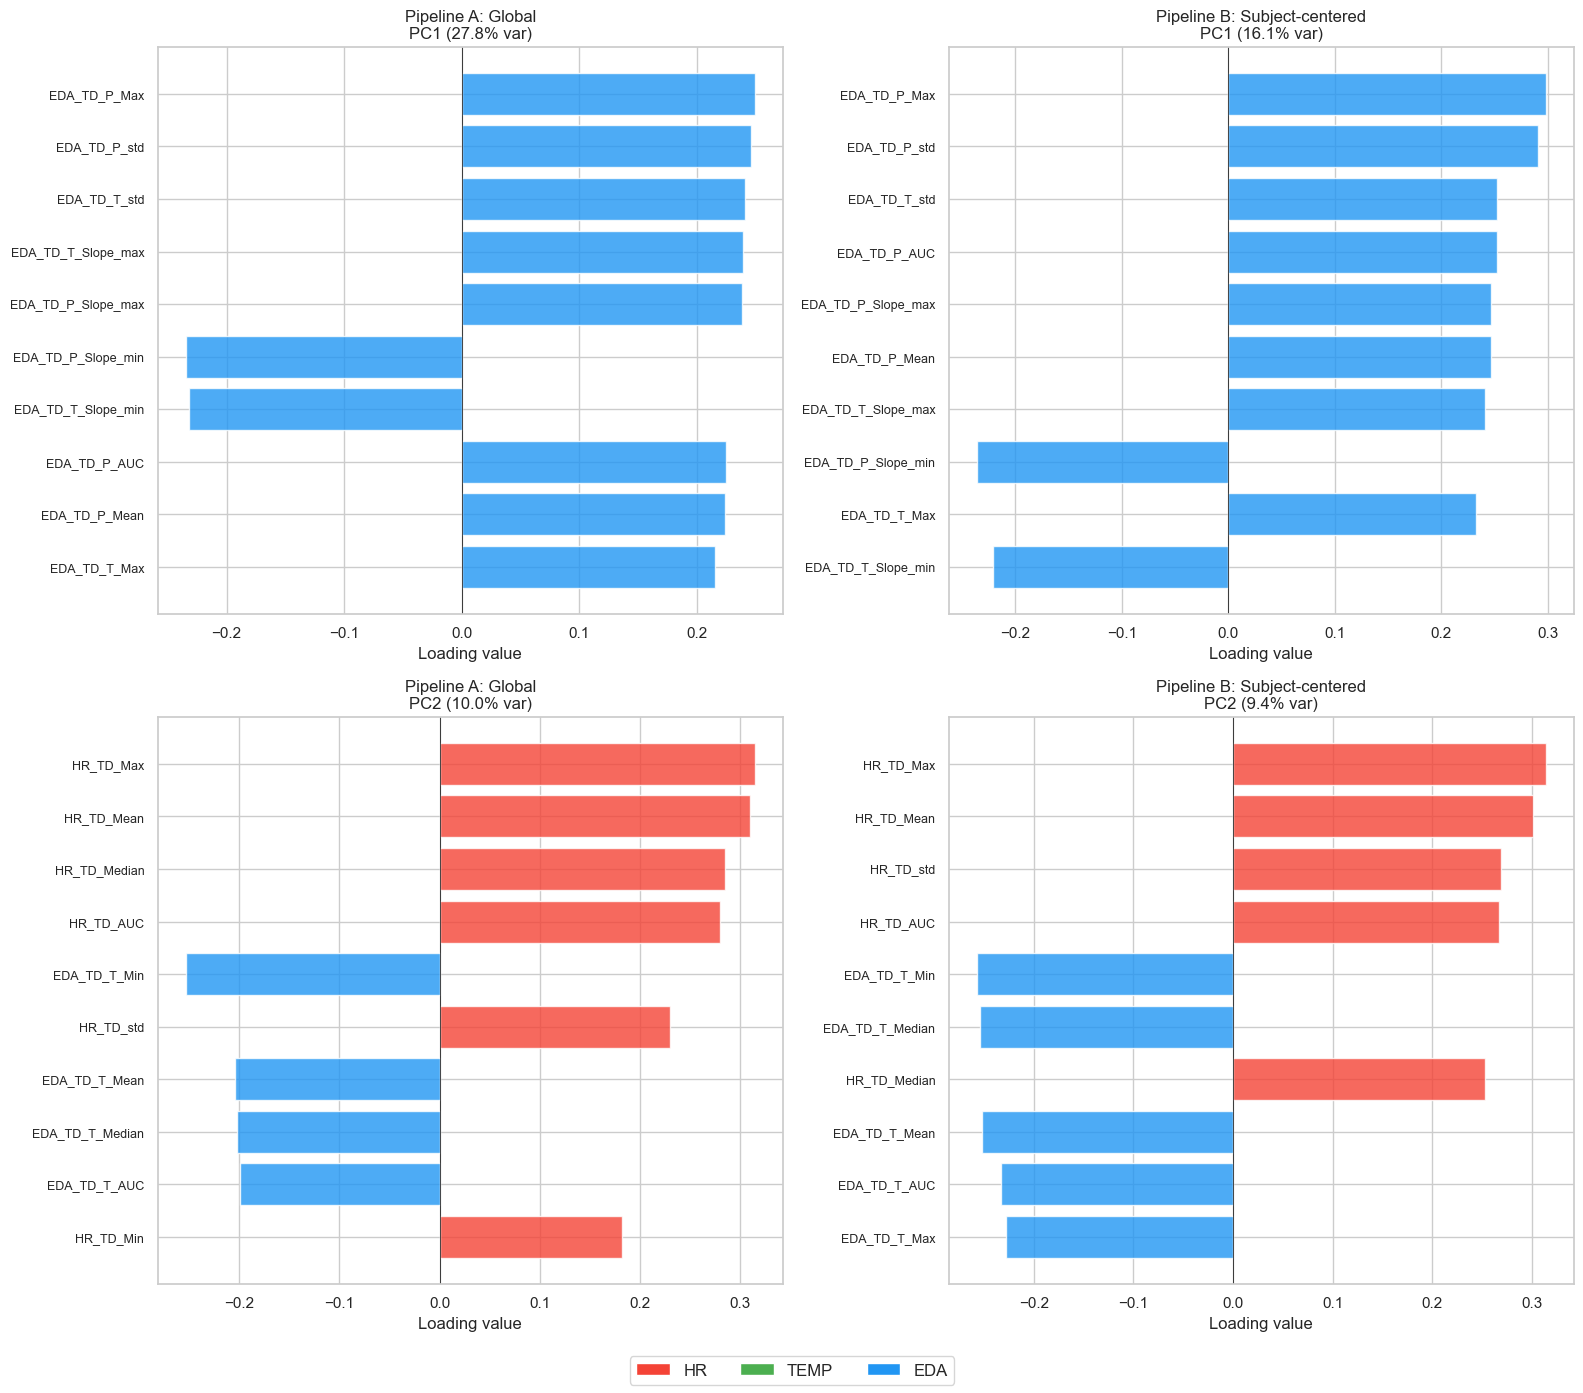

In [ ]:
# PCA loadings

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for col, (result, pipeline_name) in enumerate([
    (pca_global, "Pipeline A: Global"),
    (pca_centered, "Pipeline B: Subject-centered"),
]):
    for row, pc_idx in enumerate([0, 1]):
        ax = axes[row, col]
        top = pca_top_loadings(result, pc_index=pc_idx, top_n=10)

        colors = []
        for feat in top["feature"]:
            if feat.startswith("HR_"):
                colors.append("#F44336")
            elif feat.startswith("TEMP_"):
                colors.append("#4CAF50")
            elif feat.startswith("EDA_"):
                colors.append("#2196F3")
            else:
                colors.append("#9E9E9E")

        ax.barh(
            range(len(top)), top["loading"].values,
            color=colors, alpha=0.8,
        )
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels(top["feature"].values, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel("Loading value")
        ax.set_title(
            f"{pipeline_name}\n"
            f"PC{pc_idx+1} ({result.explained_variance_ratio[pc_idx]:.1%} var)"
        )
        ax.axvline(x=0, color="black", linewidth=0.5)

# adding legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#F44336", label="HR"),
    Patch(facecolor="#4CAF50", label="TEMP"),
    Patch(facecolor="#2196F3", label="EDA"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(RESULTS_DIR / "pca_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# pringting the loading tabeles

print("TOP 10 LOADINGS PER PC")
print("=" * 70)

for result, name in [
    (pca_global, "Pipeline A: Global"),
    (pca_centered, "Pipeline B: Subject-centered"),
]:
    print(f"\n{'='*70}")
    print(f"  {name}")
    print(f"{'='*70}")
    for pc_idx in range(3):
        top = pca_top_loadings(result, pc_index=pc_idx, top_n=10)
        var = result.explained_variance_ratio[pc_idx]
        print(f"\n  PC{pc_idx+1} ({var:.1%} variance explained)")
        print(f"  {'Feature':<30} {'Loading':>10}")
        print(f"  {'-'*40}")
        for _, row in top.iterrows():
            print(f"  {row['feature']:<30} {row['loading']:>10.4f}")

TOP 10 LOADINGS PER PC

  Pipeline A: Global

  PC1 (27.8% variance explained)
  Feature                           Loading
  ----------------------------------------
  EDA_TD_P_Max                       0.2490
  EDA_TD_P_std                       0.2459
  EDA_TD_T_std                       0.2410
  EDA_TD_T_Slope_max                 0.2394
  EDA_TD_P_Slope_max                 0.2386
  EDA_TD_P_Slope_min                -0.2345
  EDA_TD_T_Slope_min                -0.2319
  EDA_TD_P_AUC                       0.2249
  EDA_TD_P_Mean                      0.2240
  EDA_TD_T_Max                       0.2150

  PC2 (10.0% variance explained)
  Feature                           Loading
  ----------------------------------------
  HR_TD_Max                          0.3149
  HR_TD_Mean                         0.3105
  HR_TD_Median                       0.2854
  HR_TD_AUC                          0.2802
  EDA_TD_T_Min                      -0.2534
  HR_TD_std                          0.2307
  EDA_TD_

**Loading interpretation:**

EDA features dominate PC1 in both pipelines. HR features appear in PC2-PC3.
Temperature features contribute minimally to the top components, suggesting TEMP carries less discriminative information in this dataset. 
The dominance of EDA phasic features is consistent with electrodermal activity being the most-responsive biosignal to stress in short-duration tasks.

c:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


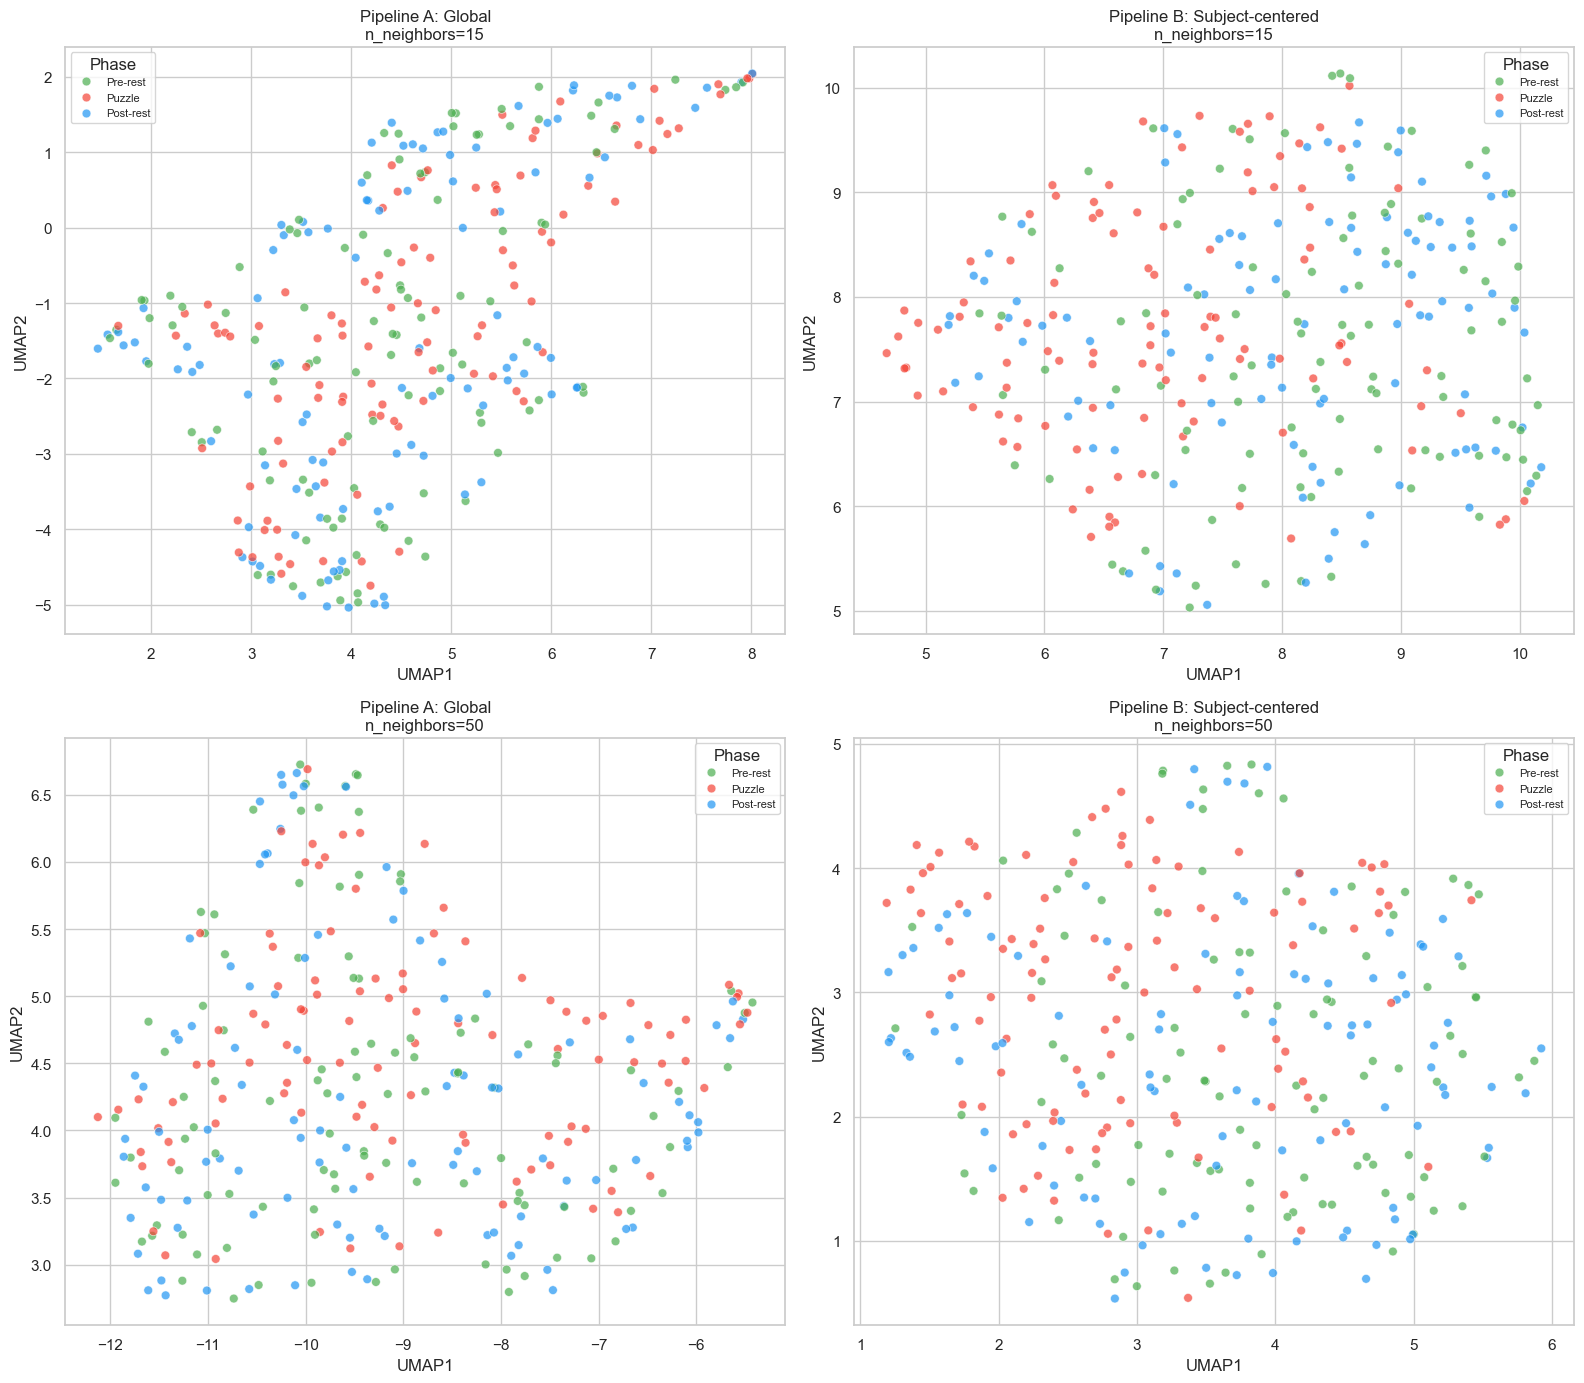

In [11]:
# UMAP comparison

try:
    from umap import UMAP
    HAS_UMAP = True
except ImportError:
    print("⚠ umap-learn not installed. Run: pip install umap-learn")
    HAS_UMAP = False

if HAS_UMAP:
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    for col, (X, pipeline_name) in enumerate([
        (X_global, "Pipeline A: Global"),
        (X_centered, "Pipeline B: Subject-centered"),
    ]):
        for row, n_neighbors in enumerate([15, 50]):
            ax = axes[row, col]

            reducer = UMAP(
                n_components=2,
                n_neighbors=n_neighbors,
                min_dist=0.1,
                random_state=42,
            )
            embedding = reducer.fit_transform(X)

            scatter_df = pd.DataFrame({
                "UMAP1": embedding[:, 0],
                "UMAP2": embedding[:, 1],
                "Phase": phase_display,
            })

            sns.scatterplot(
                data=scatter_df, x="UMAP1", y="UMAP2", hue="Phase",
                hue_order=["Pre-rest", "Puzzle", "Post-rest"],
                palette={"Pre-rest": "#4CAF50", "Puzzle": "#F44336", "Post-rest": "#2196F3"},
                alpha=0.7, s=40, ax=ax,
            )

            ax.set_title(f"{pipeline_name}\nn_neighbors={n_neighbors}")
            ax.legend(title="Phase", fontsize=8)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "umap_by_phase.png", dpi=150, bbox_inches="tight")
    plt.show()

c:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


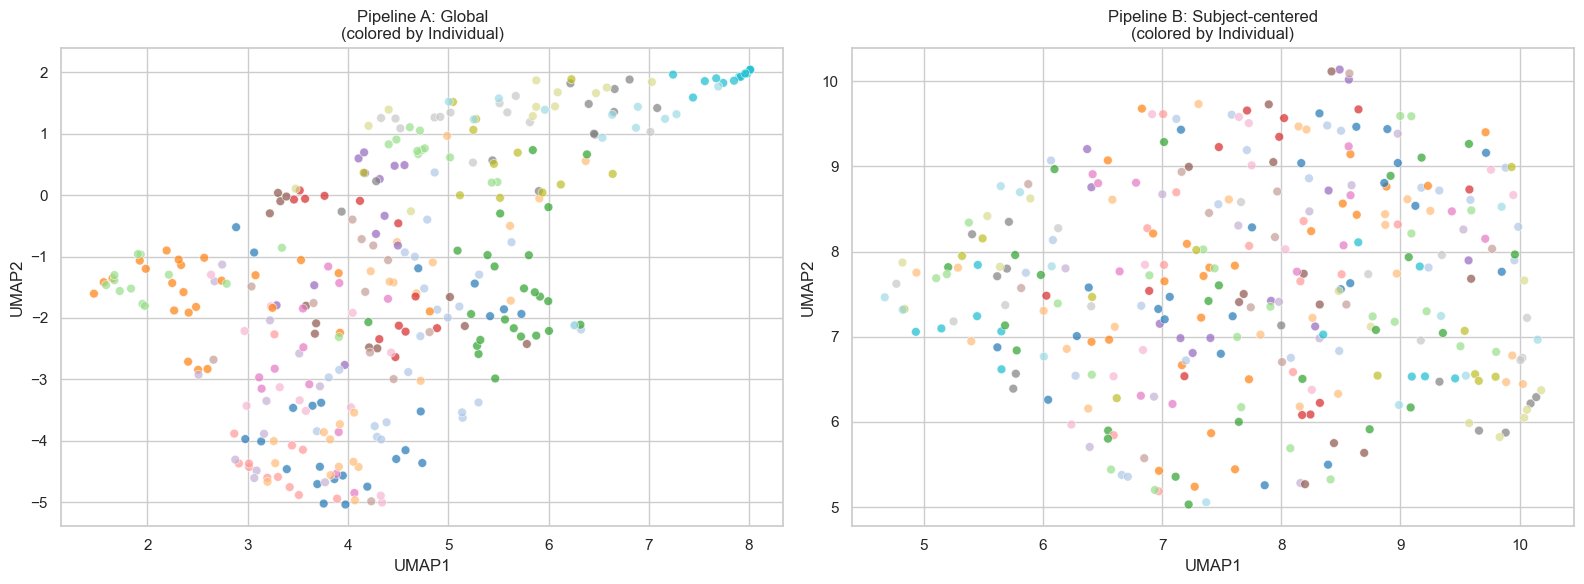

In [12]:
# UMAP coloured by individual
if HAS_UMAP:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, X, title in [
        (axes[0], X_global, "Pipeline A: Global"),
        (axes[1], X_centered, "Pipeline B: Subject-centered"),
    ]:
        reducer = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
        embedding = reducer.fit_transform(X)

        scatter_df = pd.DataFrame({
            "UMAP1": embedding[:, 0],
            "UMAP2": embedding[:, 1],
            "Individual": individual_labels.astype(str),
        })

        sns.scatterplot(
            data=scatter_df, x="UMAP1", y="UMAP2", hue="Individual",
            palette="tab20", alpha=0.7, s=40, ax=ax, legend=False,
        )
        ax.set_title(f"{title}\n(colored by Individual)")

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "umap_by_individual.png", dpi=150, bbox_inches="tight")
    plt.show()

In [14]:
# summary comparison able

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

print("=" * 80)
print("REPRESENTATION METHOD COMPARISON")
print("=" * 80)

results_table = []

for pipeline_name, X_data, pca_result in [
    ("A: Global", X_global, pca_global),
    ("B: Subject-centered", X_centered, pca_centered),
]:
    # PCA variance
    pc1_var = pca_result.explained_variance_ratio[0]
    pc2_var = pca_result.explained_variance_ratio[1]
    pcs_80 = np.searchsorted(pca_result.cumulative_variance, 0.80) + 1

    # Quick k-means on first 10 PCs to test phase separability
    n_pcs = min(10, pca_result.scores.shape[1])
    X_pca_10 = pca_result.scores[:, :n_pcs]

    km = KMeans(n_clusters=3, n_init=50, random_state=42)
    cluster_labels = km.fit_predict(X_pca_10)
    sil = silhouette_score(X_pca_10, cluster_labels)

    results_table.append({
        "Pipeline": pipeline_name,
        "PC1 var%": f"{pc1_var:.1%}",
        "PC1+PC2 var%": f"{pc1_var + pc2_var:.1%}",
        "PCs for 80%": pcs_80,
        "Silhouette (k=3)": f"{sil:.3f}",
    })

results_df = pd.DataFrame(results_table)
print(results_df.to_string(index=False))

REPRESENTATION METHOD COMPARISON
           Pipeline PC1 var% PC1+PC2 var%  PCs for 80% Silhouette (k=3)
          A: Global    27.8%        37.9%           11            0.234
B: Subject-centered    16.1%        25.5%           14            0.103


**Interpretation:** The higher silhouette score for pipeline A (0.234 vs 0.103) can be misleading. Pipeline A clusters are better separated because they capture individual identity (each person forms a tight cluster). Pipeline B has lower silhouette because after removing individual baselines, the remaining within-subject variation is more diffused and harder to cluster. A high silhouette score in this case does not mean better phase separation, it means more distinct groups exist, which in pipeline A are individuals, not phases. This can be confirmed on clustering.

In [15]:
# saving PCA results

paths_global = save_pca_results(
    pca_global, meta, RESULTS_DIR, prefix="pca_global"
)
paths_centered = save_pca_results(
    pca_centered, meta, RESULTS_DIR, prefix="pca_centered"
)

print("Saved PCA results:")
for k, v in paths_global.items():
    print(f"  Global {k}: {v}")
for k, v in paths_centered.items():
    print(f"  Centered {k}: {v}")

Saved PCA results:
  Global scores: C:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\results\embeddings\pca_global_scores.csv
  Global loadings: C:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\results\embeddings\pca_global_loadings.csv
  Global variance: C:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\results\embeddings\pca_global_variance.csv
  Centered scores: C:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\results\embeddings\pca_centered_scores.csv
  Centered loadings: C:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\results\embeddings\pca_centered_loadings.csv
  Centered variance: C:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\results\embeddings\pca_centered_variance.csv
